## Imports

In [2]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

In [3]:
import numpy as np

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Surface (1k)

## Data

In [5]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.5,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [6]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [7]:
dtype = torch.float64

train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(scaled_train, dtype=dtype), 
        torch.tensor(Y, dtype=dtype)), 
    batch_size = 8,
    shuffle = True)

x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.tensor(scaled_test, dtype=dtype)
y_test = torch.tensor(Y_test, dtype=dtype)

In [8]:
x_train.dtype

torch.float64

## Model & Training

### ANFIS

In [9]:
model = nft.rule_reduced_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    dtype=torch.float64
)

In [10]:
model.init_premises(x_train)

### Hybrid Learning Algorithm

In [11]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = nft.EarlyStopping(patience=30, delta=0.001)

In [12]:
trainer = nft.Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [13]:
Ngrow = 40
dGrow = 0.8
Nsplit = 20
eSplit = 1.2
Nvanish = 6
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.3
sonfis_early_stopping = nft.EarlyStopping(patience=8)
last_training_iteration = True

In [14]:
sonfis = nft.SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [15]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 4.957986 - validation loss: 4.888336
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 3.994351 - validation loss: 3.991523
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 6.237064 - validation loss: 6.288161
 -> ANFIS rules: 3

Iteration:  3/40 - loss: 6.027805 - validation loss: 5.850471
 -> ANFIS rules: 5

Iteration:  4/40 - loss: 6.030957 - validation loss: 5.741488
 -> ANFIS rules: 6

Iteration:  5/40 - loss: 4.268103 - validation loss: 3.997004
 -> ANFIS rules: 7

Iteration:  6/40 - loss: 4.045506 - validation loss: 3.816129
 -> ANFIS rules: 8

Iteration:  7/40 - loss: 0.360131 - validation loss: 0.512129
 -> ANFIS rules: 15

Iteration:  8/40 - loss: 0.354004 - validation loss: 0.509420
 -> ANFIS rules: 16

No more updates
Iteration:  9/40 - loss: 0.354004 - validation loss: 0.509420
 -> ANFIS rules: 16

Last training iteration
Iteration: 10/40 - loss: 0.218215 - validation loss: 0.351519

Training finished
 -> ANFIS rules: 16

CPU times: user 5min 19s, sys: 1.44

In [16]:
test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.07744512624591206
RMSE: 0.2782896445179232
MAE: 0.2056360978117651
R2: 0.978884961990292
MAPE: 11360.998882647087


In [17]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.258206084515014
RMSE: 0.5081398277197074
MAE: 0.39930468562176713
R2: 0.9319030616662594
MAPE: 4.891077590433595


# Synt 1

## Data

In [18]:
def f(x0, x1, x2):
    return (1 + x0**0.5 + x1 + x2**-1.5)

#Training
x0 = np.random.uniform(1,6,216)
x1 = np.random.uniform(1,6,216)
x2 = np.random.uniform(1,6,216)

Y = f(x0, x1, x2)


#Testing
x0_test = np.random.uniform(1.5,5.5,125)
x1_test = np.random.uniform(1.5,5.5,125)
x2_test = np.random.uniform(1.5,5.5,125)

Y_test = f(x0_test, x1_test, x2_test)

In [19]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0, x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [20]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [21]:
model = nft.rule_reduced_ANFIS(
    input_size = 3,
    num_mfs = 1,
    outputs = 1,
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [22]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = nft.EarlyStopping(patience=10, delta=0.01)

In [23]:
trainer = nft.Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [24]:
Ngrow = 30
dGrow = 0.8
Nsplit = 40
eSplit = 0.5
Nvanish = 30
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = nft.EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [25]:
sonfis = nft.SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [26]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 45.561461 - validation loss: 41.994440
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 0.021073 - validation loss: 0.026816
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 0.038635 - validation loss: 0.048186
 -> ANFIS rules: 3

Iteration:  3/40 - loss: 0.065378 - validation loss: 0.088071
 -> ANFIS rules: 3

Iteration:  4/40 - loss: 0.025399 - validation loss: 0.035220
 -> ANFIS rules: 5

No more updates
Iteration:  5/40 - loss: 0.025399 - validation loss: 0.035220
 -> ANFIS rules: 5

Last training iteration
Iteration:  6/40 - loss: 0.004963 - validation loss: 0.013292

Training finished
 -> ANFIS rules: 5

CPU times: user 4.65 s, sys: 20.3 ms, total: 4.67 s
Wall time: 984 ms


In [27]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.002658902098245969
RMSE: 0.051564543033425295
MAE: 0.04173244881328173
R2: 0.9980059118553458
MAPE: 0.006471048534982114


In [28]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.0066597937744091356
RMSE: 0.08160755954204939
MAE: 0.05609181034649056
R2: 0.9972626358039351
MAPE: 0.008423816411177577


# Synt 2

## Data

In [221]:
def f(x1, x2):
    return ((np.sin(x1)*np.sin(x2))/(x1*x2))

#Training
x1 = np.random.uniform(-5,5,196)
x2 = np.random.uniform(-5,5,196)

#noise and outliers
epsilon = 0.5

G = np.random.normal(0, 0.01, 196)
H = np.random.normal(0, 0.05, 196)
F = G * (1 - epsilon) + epsilon * H

Y = f(x1, x2) + F


#Testing
x1_test = np.random.uniform(-5,5,392)
x2_test = np.random.uniform(-5,5,392)

Y_test = f(x1_test, x2_test)

In [222]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [223]:
loader = data.DataLoader(
    data.TensorDataset(
        torch.from_numpy(scaled_train), 
        torch.from_numpy(Y)), 
    batch_size = 4, 
    shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

In [224]:
x_train.shape

torch.Size([196, 2])

## Model & Training

### ANFIS

In [225]:
model = nft.rule_reduced_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    #membership_function=nft.Gaussian_MF
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [226]:
loss_fn = nn.functional.mse_loss
loss_fn = nn.functional.l1_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = nft.EarlyStopping(patience=15)

In [227]:
trainer = nft.Hybrid_learning_algorithm(
    epochs=200,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [228]:
Ngrow = 20
dGrow = 0.8
Nsplit = 30
eSplit = 0.7
Nvanish = 20
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
#sonfis_early_stopping = nft.EarlyStopping(patience=15, delta=0.01)
sonfis_early_stopping = None
last_training_iteration = True

In [229]:
sonfis = nft.alt_SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [230]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 0.493779 - validation loss: 0.508436
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 0.187437 - validation loss: 0.177649
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 0.244501 - validation loss: 0.224041
 -> ANFIS rules: 3

Iteration:  3/40 - loss: 0.251826 - validation loss: 0.218055
 -> ANFIS rules: 4

Iteration:  4/40 - loss: 0.083660 - validation loss: 0.094535
 -> ANFIS rules: 7

Iteration:  5/40 - loss: 0.166202 - validation loss: 0.201484
 -> ANFIS rules: 8

Iteration:  6/40 - loss: 0.283254 - validation loss: 0.251482
 -> ANFIS rules: 8

Iteration:  7/40 - loss: 0.241114 - validation loss: 0.222997
 -> ANFIS rules: 7

Iteration:  8/40 - loss: 0.272435 - validation loss: 0.248909
 -> ANFIS rules: 5

Iteration:  9/40 - loss: 0.320379 - validation loss: 0.315150
 -> ANFIS rules: 5

Iteration: 10/40 - loss: 0.141622 - validation loss: 0.179820
 -> ANFIS rules: 7

No more updates
Iteration: 11/40 - loss: 0.141622 - validation loss: 0.179820
 -> ANFIS rules: 7



In [231]:
model.num_mfs

7

In [232]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.0017299842760661079
RMSE: 0.04159307966556586
MAE: 0.032248047284810996
R2: 0.9766686114216003
MAPE: 1.6039366870047456


In [233]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.001844068508889802
RMSE: 0.04294261879403493
MAE: 0.032796542688031415
R2: 0.9733903777056531
MAPE: 1.7541435737911644


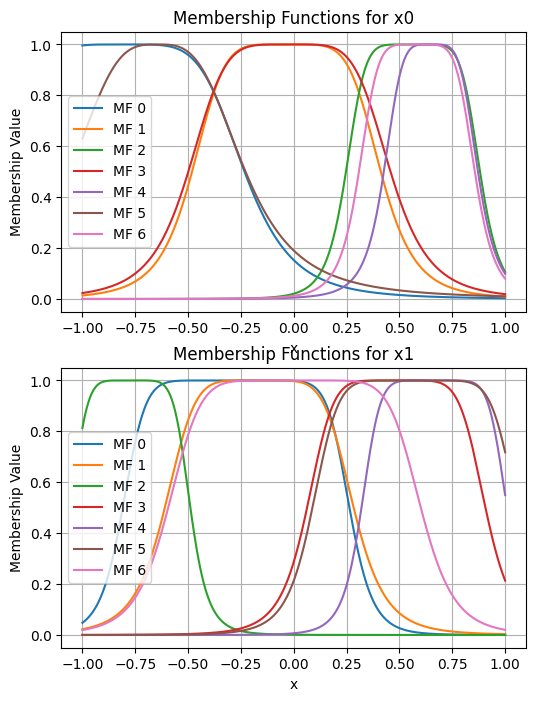

In [234]:
model.plot_premises(group_by_dim=True)

In [235]:
model.consequents_structure

[         c0 (x0)   c1 (x1)        c2
 rule 1 -0.252323 -0.433189 -0.537880
 rule 2 -0.497902  1.865109  1.319500
 rule 3  0.232266  0.056634 -0.106922
 rule 4  0.112348 -0.966296  0.553341
 rule 5  0.006673 -0.095812  0.144624
 rule 6 -0.064559  0.168514 -0.132062
 rule 7 -0.823598 -0.260447  0.427478]